# friant_uncertainty_viz.ipynb

Plot the MLR basin-SWE prediction with an uncertainty band derived from the ranked pillow
combinations, one panel per decade.

`ensemble_tidy_wy{YYYY}.csv` is long: one row per `(date, isImpute, elev_band, rank)`.
Rank 1 is the published prediction (identical to `prediction_mm_wy{YYYY}_combination.csv`,
modulo that the published file is `int()`-truncated). Ranks 2..N are the next-best pillow
combinations by cross-validated adjusted R2 -- they were already being computed inside
`identify_best_stations` and discarded; the spread across them is the uncertainty estimate.

Three things worth knowing before reading the figure:

1. **Do not pool the two imputation modes.** `drop NaNs` and `predict NaNs` search different
   candidate pools (`baseline_pils` vs `pils_removed`) against different training tables, and
   the impute mode scores partly against synthetic predictors. Select one; that is what
   `MODEL` does.
2. **Rank is not a stable entity across time.** The available pillows change, so rank 2 on one
   date can be a different combination than rank 2 on the next. That is why this plots a band
   and never a per-rank line.
3. **`ADJ_R2_TOL` matters.** In some elevation bands adjusted R2 falls >0.5 between rank 1 and
   rank 10, meaning the tail members are models the selection criterion already rejected.
   Including them widens the band without adding information. Set a tolerance to keep only
   members within that distance of rank 1.

## Inputs

In [2]:
VERSION   = 'v7_ens'          # output dir under FRIANT/, e.g. v6_pre, v7_ens
MODEL     = 'predict NaNs'    # 'drop NaNs' or 'predict NaNs'

ELEV_BAND = 'total'           # 'total' = basin mean; or '<7000' ... '>12000'
BAND      = 'p10_p90'         # 'p10_p90' | 'min_max' | 'sd'
N_RANKS   = 10                # use ranks 1..N_RANKS
ADJ_R2_TOL = None             # e.g. 0.05 -> drop members >0.05 below rank 1's adj_r2. None = keep all
SHOW_ASO  = True              # mark ASO flight dates (where observed truth exists)

BASIN     = 'FRIANT'
SEASONAL  = 'season'
SAVE_FIG  = None              # e.g. 'friant_uncertainty_v7_ens_predictNaNs.png'

## Load

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path(f'/home/rossamower/work/aso/data/mlr_prediction/{BASIN}')
SRC  = ROOT / VERSION / SEASONAL

files = sorted(SRC.glob('ensemble_tidy_wy*.csv'))
if not files:
    raise SystemExit(f'no ensemble_tidy_wy*.csv under {SRC}')

frames = []
for f in files:
    wy = int(re.search(r'wy(\d{4})', f.name).group(1))
    df = pd.read_csv(f)
    df['water_year'] = wy
    frames.append(df)
e = pd.concat(frames, ignore_index=True)
e['date'] = pd.to_datetime(e['date'])

years = sorted(e.water_year.unique())
missing = [y for y in range(min(years), max(years) + 1) if y not in years]
print(f'loaded {len(files)} water years: {min(years)}-{max(years)}   rows={len(e):,}')
if missing:
    print(f'MISSING (sweep may still be running): {missing}')
print('columns:', list(e.columns))

loaded 26 water years: 1980-2006   rows=1,446,782
MISSING (sweep may still be running): [1989]
columns: ['modelID', 'elev_band', 'isImpute', 'date', 'rank', 'adj_r2', 'pillows', 'pred_mm', 'pred_acreFt', 'n_QA', 'n_baseline', 'pillows_QA', 'water_year']


## Aggregate to one band per date

`isImpute=False` is `drop NaNs`; `isImpute=True` is `predict NaNs`. Rank 1 is taken directly
rather than joined from `prediction_mm_*.csv`, so the centre line and the band come from the
same full-precision source -- mixing a truncated centre with an untruncated band can put the
line marginally outside its own envelope.

In [4]:
IMPUTE_FLAG = {'drop NaNs': False, 'predict NaNs': True}[MODEL]

d = e[(e.isImpute == IMPUTE_FLAG) & (e.elev_band == ELEV_BAND)].copy()
d = d[d['rank'] <= N_RANKS]
d = d.dropna(subset=['pred_mm'])

if ADJ_R2_TOL is not None:
    top = d.groupby('date')['adj_r2'].transform('max')
    keep = d['adj_r2'] >= (top - ADJ_R2_TOL)
    print(f'ADJ_R2_TOL={ADJ_R2_TOL}: keeping {keep.sum():,}/{len(d):,} members '
          f'({100*keep.mean():.1f}%)')
    d = d[keep]

g = d.groupby('date')['pred_mm']
agg = pd.DataFrame({
    'rank1': d[d['rank'] == 1].set_index('date')['pred_mm'],
    'mean' : g.mean(),
    'sd'   : g.std(),
    'lo_mm': g.min(),
    'hi_mm': g.max(),
    'p10'  : g.quantile(0.10),
    'p90'  : g.quantile(0.90),
    'n'    : g.size(),
}).sort_index()

# availability, recorded per date by the runner (not inferred -- inferring it from the
# ensemble output once produced a spurious result).
if 'n_QA' in d.columns:
    agg['n_QA'] = d.groupby('date')['n_QA'].first()
    agg['n_baseline'] = d.groupby('date')['n_baseline'].first()

if BAND == 'p10_p90':
    agg['lo'], agg['hi'], band_label = agg.p10, agg.p90, 'p10-p90 of top-%d' % N_RANKS
elif BAND == 'min_max':
    agg['lo'], agg['hi'], band_label = agg.lo_mm, agg.hi_mm, 'min-max of top-%d' % N_RANKS
elif BAND == 'sd':
    agg['lo'], agg['hi'] = agg.rank1 - agg.sd, agg.rank1 + agg.sd
    band_label = 'rank1 +/- 1 sd'
else:
    raise ValueError(BAND)

print(f'{len(agg):,} dates  |  band = {band_label}')
agg.head()

9,471 dates  |  band = p10-p90 of top-10


,rank1,mean,sd,lo_mm,hi_mm,p10,p90,n,n_QA,n_baseline,lo,hi
date,,,,,,,,,,,,
1979-10-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0
1979-10-06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7,5,3,0.0,0.0


## Figure -- one panel per decade

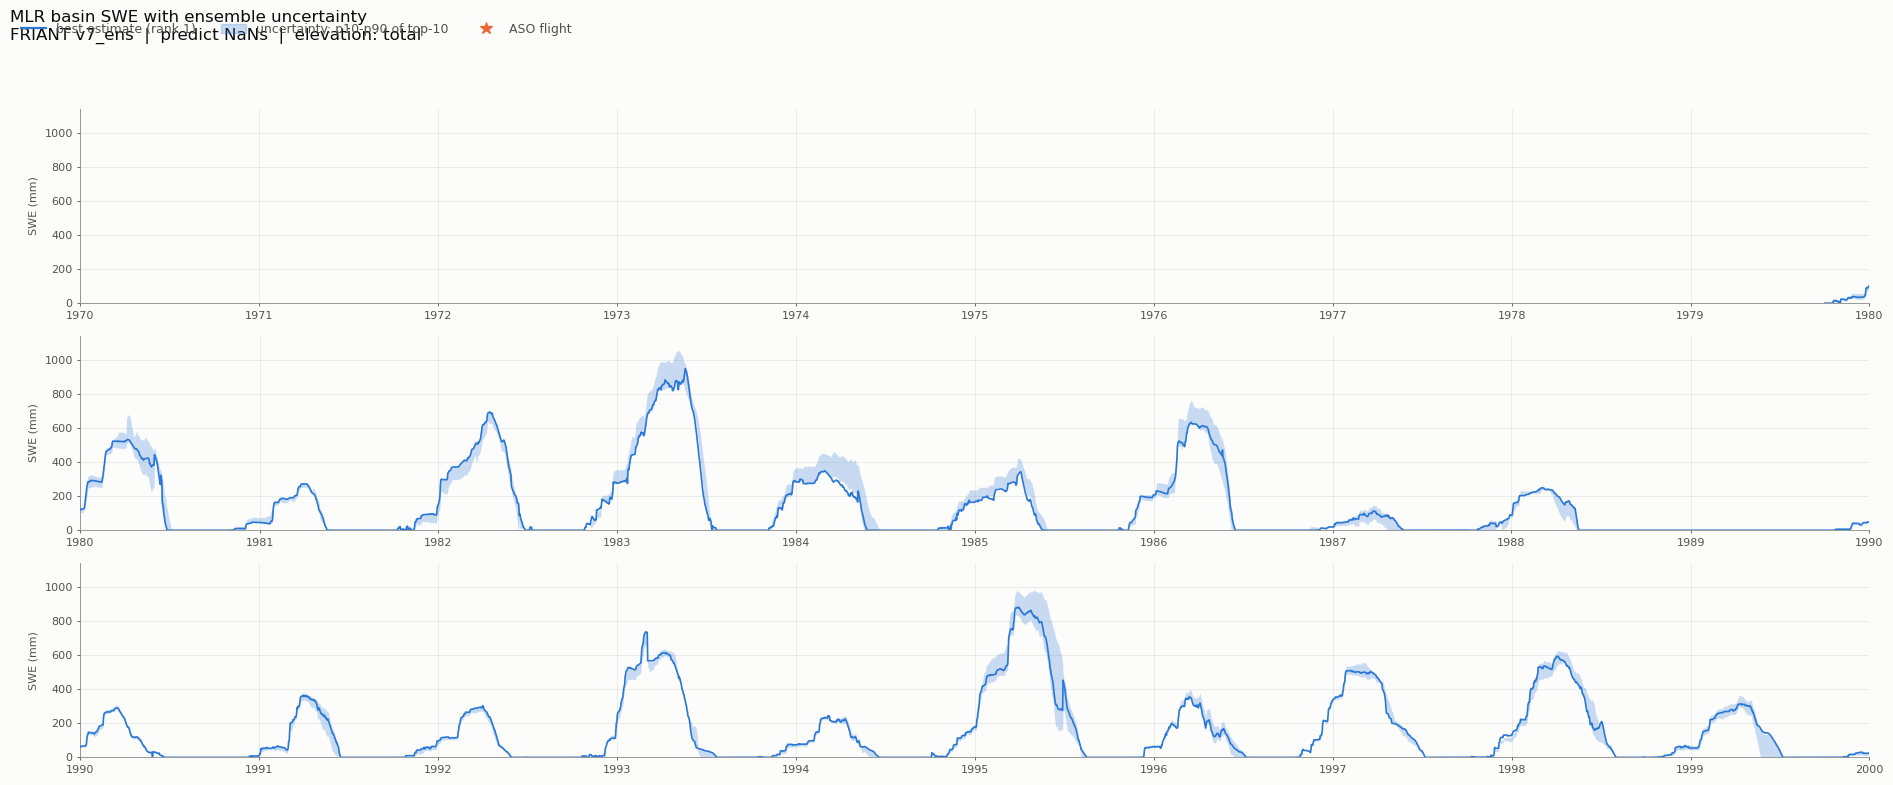

In [5]:
# Categorical palette slots 1-2 of the validated default set. One data series plus its band,
# so the band reuses the line's hue at low alpha (same entity, not a second category); the
# ASO markers get a distinct hue because they are a different kind of thing (observed truth).
C_LINE  = '#2a78d6'   # slot 1, blue
C_ASO   = '#eb6834'   # slot 2, orange
SURFACE = '#fcfcfb'
INK, INK2, MUTED = '#0b0b0b', '#52514e', '#8a8985'

aso_dates = []
if SHOW_ASO:
    try:
        ts = xr.open_dataset(f'/home/rossamower/work/aso/data/aso/{BASIN}/ASO_50M_SWE_TSERIES.nc')
        aso_dates = pd.DatetimeIndex(pd.to_datetime(ts.date.values)).normalize()
    except Exception as exc:
        print('ASO flight dates unavailable:', exc)

# Decade panels on WATER-year boundaries, not calendar years. A water year starts Oct 1 of
# the previous calendar year, so WY1980 begins 1979-10-01 -- taking the decade from the
# minimum *date* would put the first panel at 1970. Panel (a, b) spans WY a..b-1, i.e.
# Oct 1 of (a-1) through Oct 1 of (b-1).
wy_lo = (min(years) // 10) * 10
wy_hi = max(years)
edges = [y for y in range(wy_lo, wy_hi + 11, 10)]
panels = [(a, b) for a, b in zip(edges[:-1], edges[1:]) if a <= wy_hi]

fig, axes = plt.subplots(len(panels), 1, figsize=(19, 2.6 * len(panels)),
                         facecolor=SURFACE)
axes = np.atleast_1d(axes)
ymax = float(np.nanmax([agg.hi.max(), agg.rank1.max()])) * 1.08

for ax, (y0, y1) in zip(axes, panels):
    m = (agg.index >= f'{y0-1}-10-01') & (agg.index < f'{y1-1}-10-01')
    a = agg[m]

    ax.set_facecolor(SURFACE)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(MUTED); ax.spines[s].set_linewidth(0.6)
    ax.grid(True, color=MUTED, alpha=0.20, linewidth=0.5)
    ax.set_axisbelow(True)
    ax.tick_params(colors=INK2, labelsize=8, length=2, width=0.6)

    if len(a):
        ax.fill_between(a.index, a.lo, a.hi, color=C_LINE, alpha=0.25, lw=0, zorder=2)
        ax.plot(a.index, a.rank1, color=C_LINE, lw=1.2, zorder=3, solid_capstyle='round')

    if len(aso_dates):
        f = aso_dates[(aso_dates >= f'{y0-1}-10-01') & (aso_dates < f'{y1-1}-10-01')]
        if len(f):
            yv = agg.rank1.reindex(f).values
            ax.scatter(f, yv, s=26, marker='*', color=C_ASO, zorder=4,
                       edgecolor=SURFACE, linewidth=0.5)

    ax.set_xlim(pd.Timestamp(f'{y0-1}-10-01'), pd.Timestamp(f'{y1-1}-10-01'))
    ax.set_ylim(0, ymax)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_ylabel('SWE (mm)', fontsize=8, color=INK2)

handles = [
    plt.Line2D([], [], color=C_LINE, lw=1.6, label='best estimate (rank 1)'),
    plt.Rectangle((0, 0), 1, 1, color=C_LINE, alpha=0.25, label=f'uncertainty: {band_label}'),
]
if len(aso_dates):
    handles.append(plt.Line2D([], [], color=C_ASO, marker='*', lw=0, markersize=9,
                              label='ASO flight'))
fig.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.006, 0.998),
           ncol=3, frameon=False, fontsize=9, labelcolor=INK2)

sub = f'{BASIN} {VERSION}  |  {MODEL}  |  elevation: {ELEV_BAND}'
if ADJ_R2_TOL is not None:
    sub += f'  |  adj-R2 within {ADJ_R2_TOL} of rank 1'
fig.suptitle(f'MLR basin SWE with ensemble uncertainty\n{sub}',
             x=0.006, ha='left', y=1.0, fontsize=12, color=INK)
fig.tight_layout(rect=[0.008, 0, 1, 0.955])

if SAVE_FIG:
    fig.savefig(SAVE_FIG, dpi=200, facecolor=SURFACE, bbox_inches='tight')
    print('wrote', SAVE_FIG)
plt.show()

## Does spread depend on pillow availability?

This is the question the ensemble was built to answer, and it needs care. Relative spread
(`sd` as a percent of rank 1) explodes whenever rank 1 is near zero, so early-season dates
with no snow will dominate any percentage-based comparison and look like huge uncertainty.
Below, absolute spread in mm is reported alongside, and low-SWE dates are excluded.

In [6]:
MIN_SWE_MM = 50   # exclude near-zero dates: a percentage of ~0 is not an uncertainty signal

a = agg[agg.rank1 >= MIN_SWE_MM].copy()
a['sd_pct'] = 100 * a.sd / a.rank1

if 'n_QA' in a.columns:
    by = a.groupby('n_QA').agg(dates=('sd', 'size'), mean_rank1_mm=('rank1', 'mean'),
                               mean_sd_mm=('sd', 'mean'), median_sd_pct=('sd_pct', 'median'))
    print(f'spread vs available pillows (dates with rank1 >= {MIN_SWE_MM} mm)')
    display(by.round(1))
    if len(by) > 1:
        r = a[['n_QA', 'sd']].corr().iloc[0, 1]
        rp = a[['n_QA', 'sd_pct']].corr().iloc[0, 1]
        print(f'corr(n_QA, absolute sd) = {r:+.3f}   corr(n_QA, sd %) = {rp:+.3f}')
    else:
        print('only one n_QA value present -- needs more water years to be informative')
else:
    print('n_QA not in this file (predates the column); rerun the sweep to populate it')

print()
print('spread by decade')
dec = a.assign(decade=(a.index.year // 10) * 10).groupby('decade').agg(
    dates=('sd', 'size'), mean_rank1_mm=('rank1', 'mean'),
    mean_sd_mm=('sd', 'mean'), median_sd_pct=('sd_pct', 'median'))
display(dec.round(1))

spread vs available pillows (dates with rank1 >= 50 mm)


,dates,mean_rank1_mm,mean_sd_mm,median_sd_pct
n_QA,,,,
3,10,123.0,7.9,7.8
4,19,204.4,43.3,17.4
5,88,411.4,38.9,10.5
6,63,419.6,104.2,27.4
8,21,172.3,35.9,20.8
9,455,266.8,26.0,8.3
10,347,379.8,46.1,10.8
11,388,286.8,46.6,15.8
12,304,217.0,32.0,13.2


corr(n_QA, absolute sd) = -0.155   corr(n_QA, sd %) = -0.104

spread by decade


,dates,mean_rank1_mm,mean_sd_mm,median_sd_pct
decade,,,,
1970,7,91.6,16.0,19.6
1980,1554,307.6,42.3,13.3
1990,1937,268.9,27.7,8.3
2000,1338,287.9,34.5,11.0
